# Ptychography tutorial 07 — multi-GPU & memory budgets

Demonstrates running iterative ptychography across multiple GPUs and how to fit datasets larger than a single GPU's VRAM. Passing a list of GPU indices to `device` is the only change from a single-GPU workflow — both pixelated and DIP object models are supported.

**When to use multi-GPU:**
- Your dataset exceeds a single GPU's VRAM (each GPU holds only ~1/W of the diffraction data)
- You want faster wall-clock time on long reconstructions

**How it works:**
- Diffraction patterns are sharded across ranks: each GPU holds ~N/W of the scan positions
- Object and probe are replicated on every GPU
- After each backward pass, gradients are averaged across all GPUs via NCCL all-reduce, so every GPU updates identically
- In a notebook, `device=[0, 1, ...]` spawns worker processes automatically — no `torchrun` needed

## Memory budget

For a dataset with N scan positions and Qr × Qc detector pixels, on W GPUs:

| Resident object | Approx. size (per GPU) | Notes |
|---|---|---|
| Diffraction targets (sharded) | `(N/W) · Qr · Qc · 4 B` | float32; the dominant cost for large datasets |
| Object (replicated) | `slices · Hobj · Wobj · 8 B` | complex64 |
| Probe (replicated) | `num_probes · Qr · Qc · 8 B` | complex64 |
| Adam optimizer state | ≈ 2× the params it tracks | obj, probe, descan/positions (if learned) |
| Forward + backward transients | `~(batch_size/W) · num_probes · Qr · Qc · 8 B × graph_factor` | each GPU processes `batch_size / W` samples per step, so adding GPUs shrinks this; reduce `batch_size` if tight |

Two knobs control where the diffraction targets live:

- `pdset.target_residency = "device"` (**default**) — targets live on the GPU. Fastest, but the sharded target tensor must fit in each GPU's VRAM.
- `pdset.target_residency = "cpu"` — targets live in CPU RAM and are streamed to the GPU per-batch. Lets you reconstruct datasets larger than the combined GPU VRAM (limited only by host RAM). Combine with `reconstruct(num_workers=2, ...)` so a background DataLoader prefetches and pin-memory transfers overlap with compute.

**Batch size with multi-GPU.** `batch_size` is the *global* batch size: the number of samples contributing to one optimizer step, regardless of how many GPUs are used. With W GPUs, each rank processes `batch_size / W` samples per step (a warning is emitted if `batch_size` isn't evenly divisible by W) and gradients are averaged across ranks, so the optimizer sees the same effective batch as a single-GPU run. The same `batch_size` therefore reproduces the same optimization trajectory (loss curve) on 1 or N GPUs. Therefore, per-GPU transient memory scales with `batch_size / W`, so adding GPUs reduces per-GPU memory at a fixed `batch_size`.

**Startup overhead:** Each multi-GPU `reconstruct()` call pays a fixed cost for process spawning, NCCL initialization, and state serialization (~10 s).

Arthur McCray  
May 2026

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import quantem as em
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d, OptimizerParams, SchedulerParams
from quantem.core.visualization import show_2d
from quantem.diffractive_imaging import (
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
    PtychographyDatasetRaster,
)

print(f"quantEM version: {em.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPUs available: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    vram_gb = props.total_memory / 1024**3
    print(f"  GPU {i}: {props.name} ({vram_gb:.1f} GB VRAM)")

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quantEM version: 0.1.8
PyTorch version: 2.12.0+cu130
GPUs available: 4
  GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GB VRAM)
  GPU 1: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GB VRAM)
  GPU 2: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GB VRAM)
  GPU 3: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GB VRAM)


## Load the ducky dataset

We use the same simulated ducky dataset as in other tutorials. In practice the multi-GPU memory benefit becomes critical when the full diffraction array (N × Qr × Qc float32) approaches single-GPU VRAM limits.

In [3]:
filepath = Path("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dset: Dataset4dstem = em.io.load(filepath)
print(dset)

PROBE_ENERGY = 80e3    # eV
PROBE_SEMIANGLE = 20   # mrad
PROBE_DEFOCUS = 500    # Angstroms

quantem Dataset named 'ducky_251105_clean'
  shape: (37, 37, 200, 200)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [4.    4.    0.025 0.025]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'


## Preprocess

Dataset preprocessing runs once on the main process. Worker processes receive the preprocessed state and each shards only its slice to GPU memory.

In [4]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=False,
    plot_com=False,
)

detector_model = DetectorPixelated()

# Adjust to the GPU indices available on your machine
GPU_IDS = [0, 1]  # or list(range(torch.cuda.device_count()))
print(f"Using GPUs: {GPU_IDS}")

Calculated best fit rotation = 0 degrees.


Normalizing intensities: 100%|██████████| 1369/1369 [00:01<00:00, 717.00probe position/s]


Using GPUs: [0, 3]


## Pixelated — single GPU

Iter 500/500, Loss: 4.394e+00: 100%|██████████| 500/500 [00:30<00:00, 16.35it/s]


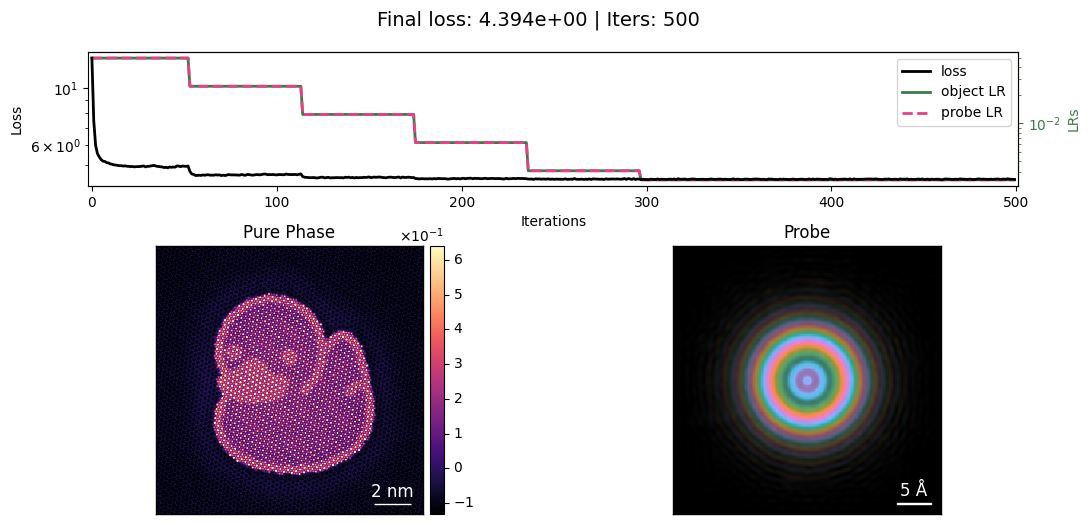

1 GPU — 500 iters — 31.9s


In [5]:
ptycho_1gpu = Ptychography.from_models(
    dset=pdset,
    obj_model=ObjectPixelated.from_uniform(obj_type="pure_phase", num_slices=1),
    probe_model=ProbePixelated.from_params(
        probe_params={"energy": PROBE_ENERGY, "defocus": PROBE_DEFOCUS, "semiangle_cutoff": PROBE_SEMIANGLE}
    ),
    detector_model=detector_model,
    rng=42,
)
ptycho_1gpu.preprocess(obj_padding_px=(32, 32))

pix_opt = {
    "object": OptimizerParams.Adam(lr=5e-2),
    "probe": OptimizerParams.Adam(lr=5e-2),
}
sched = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}

t0 = time.perf_counter()
ptycho_1gpu.reconstruct(
    num_iters=500,
    reset=True,
    optimizer_params=pix_opt,
    scheduler_params=sched,
    batch_size=128,
    device=GPU_IDS[0],
).visualize()
t_1gpu = time.perf_counter() - t0
print(f"1 GPU — {ptycho_1gpu.num_iters} iters — {t_1gpu:.1f}s")

## Pixelated — multi-GPU

Pass a list of GPU indices. Everything else is identical to the single-GPU call.

Iter 500/500, Loss: 4.385e+00: 100%|██████████| 500/500 [00:16<00:00, 30.70it/s]


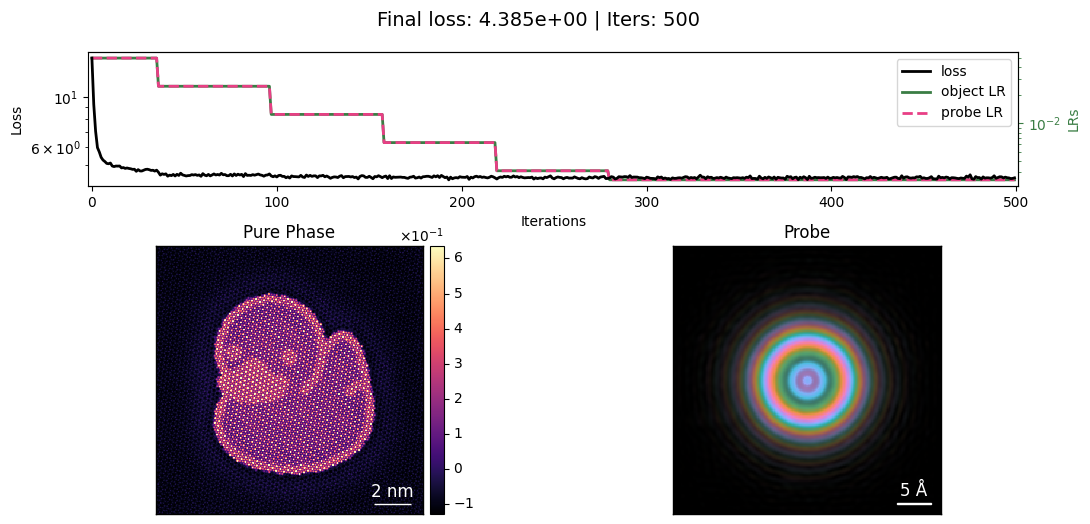

2 GPUs — 500 iters — 22.8s


In [ ]:
ptycho_mgpu = Ptychography.from_models(
    dset=pdset,
    obj_model=ObjectPixelated.from_uniform(obj_type="pure_phase", num_slices=1),
    probe_model=ProbePixelated.from_params(
        probe_params={"energy": PROBE_ENERGY, "defocus": PROBE_DEFOCUS, "semiangle_cutoff": PROBE_SEMIANGLE}
    ),
    detector_model=detector_model,
    rng=42,
)
ptycho_mgpu.preprocess(obj_padding_px=(32, 32))

# batch_size is GLOBAL: 128 samples contribute to each optimizer step no matter how
# many GPUs are used. Each GPU processes 128 // len(GPU_IDS) samples per step, so this
# run follows the same optimization trajectory as the single-GPU baseline above while
# splitting the per-step work (and transient memory) across the GPUs.
pix_opt_mgpu = {
    "object": OptimizerParams.Adam(lr=5e-2),
    "probe": OptimizerParams.Adam(lr=5e-2),
}


t0 = time.perf_counter()
ptycho_mgpu.reconstruct(
    num_iters=500,
    reset=True,
    optimizer_params=pix_opt_mgpu,
    scheduler_params=sched,
    batch_size=128, 
    device=GPU_IDS,
).visualize()
t_mgpu = time.perf_counter() - t0
print(f"{len(GPU_IDS)} GPUs — {ptycho_mgpu.num_iters} iters — {t_mgpu:.1f}s")

## Pixelated: comparison

Because `batch_size` is global, both runs use the same effective batch per optimizer step (128) — the multi-GPU loss curve should track the single-GPU one essentially exactly, just with a shorter wall-clock time.

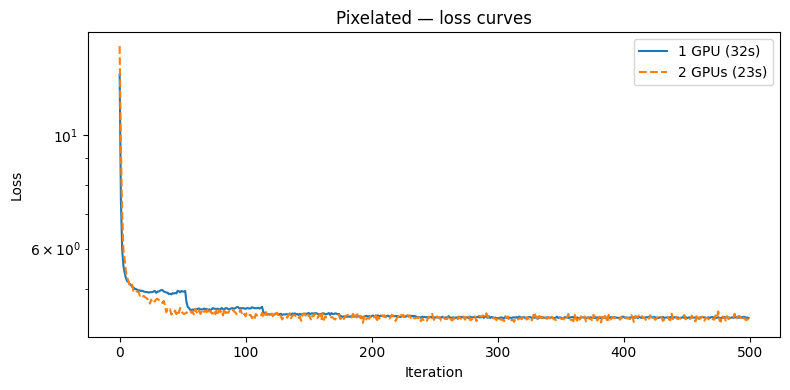

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': '1 GPU | 500 iters'}>,
        <Axes: title={'center': '2 GPUs | 500 iters'}>], dtype=object))

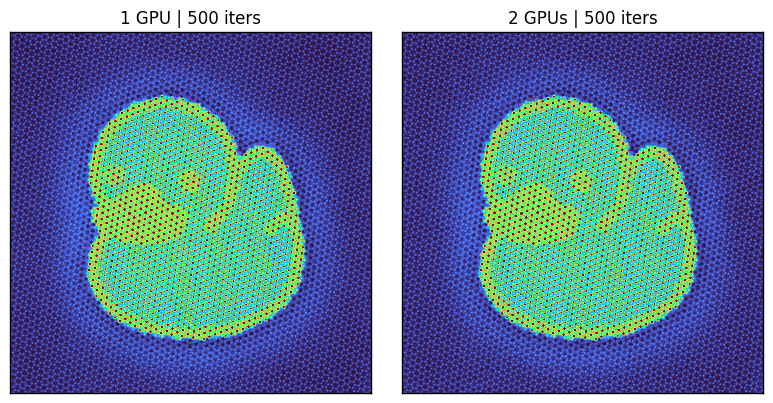

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ptycho_1gpu._iter_losses, label=f"1 GPU ({t_1gpu:.0f}s)")
ax.plot(ptycho_mgpu._iter_losses, label=f"{len(GPU_IDS)} GPUs ({t_mgpu:.0f}s)", linestyle="--")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.set_title("Pixelated — loss curves")
plt.tight_layout()
plt.show()

ph_1gpu = ptycho_1gpu.obj_cropped.sum(0)
ph_mgpu = ptycho_mgpu.obj_cropped.sum(0)
show_2d(
    [ph_1gpu, ph_mgpu],
    cmap="turbo",
    title=[
        f"1 GPU | {ptycho_1gpu.num_iters} iters",
        f"{len(GPU_IDS)} GPUs | {ptycho_mgpu.num_iters} iters",
    ],
)

## DIP — setup

Deep Image Prior replaces the pixelated object and probe with small CNNs. The multi-GPU path works identically — network weights play the role of the object parameters, and their gradients are all-reduced across ranks after each backward pass.

Workflow:
1. Build `ObjectDIP` and `ProbeDIP` from the converged pixelated reconstruction
2. Pretrain each network to match the pixelated state
3. Deep-copy the pretrained weights so the 1-GPU and multi-GPU runs start from an identical point

Iter 20/20, Loss: 4.949e+00: 100%|██████████| 20/20 [00:01<00:00, 16.45it/s]


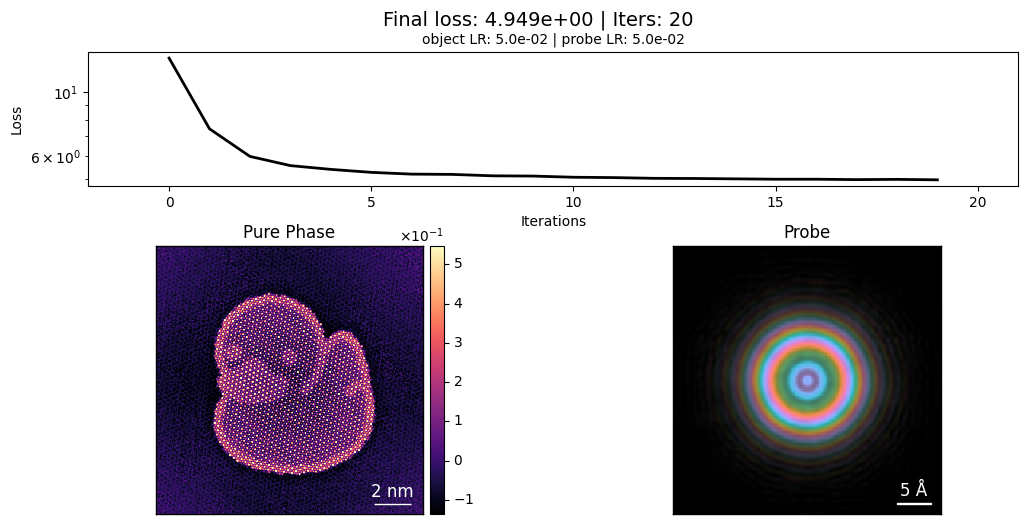

In [8]:
ptycho_pix2 = Ptychography.from_ptychography(
    ptycho=ptycho_1gpu,
)
ptycho_pix2.reconstruct(
    num_iters=20,
    reset=True,
    device=GPU_IDS[0],
).visualize()

Iter 100/100, Loss: 8.668e-04, : 100%|██████████| 100/100 [00:01<00:00, 53.15it/s]


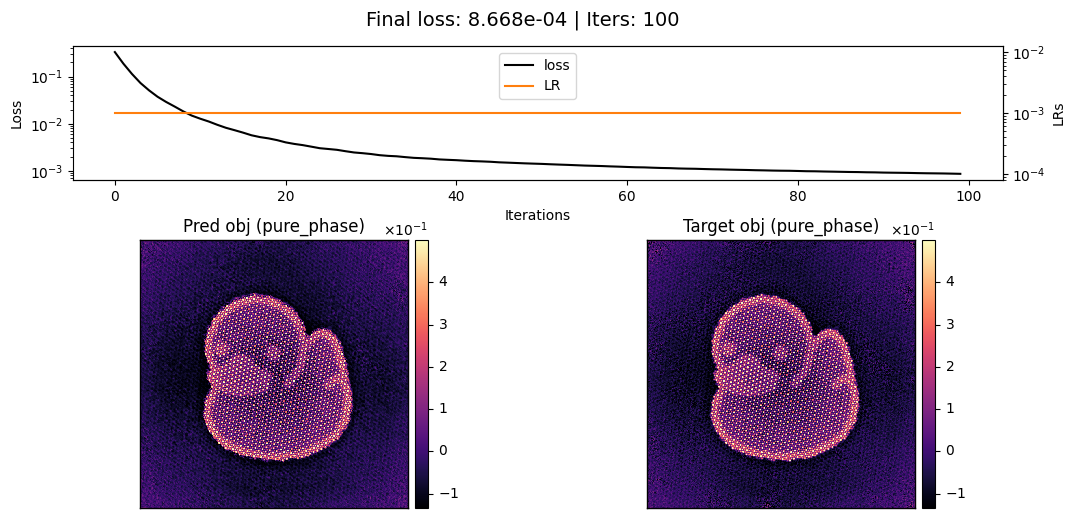

Iter 100/100, Loss: 5.940e-03, : 100%|██████████| 100/100 [00:01<00:00, 51.29it/s]


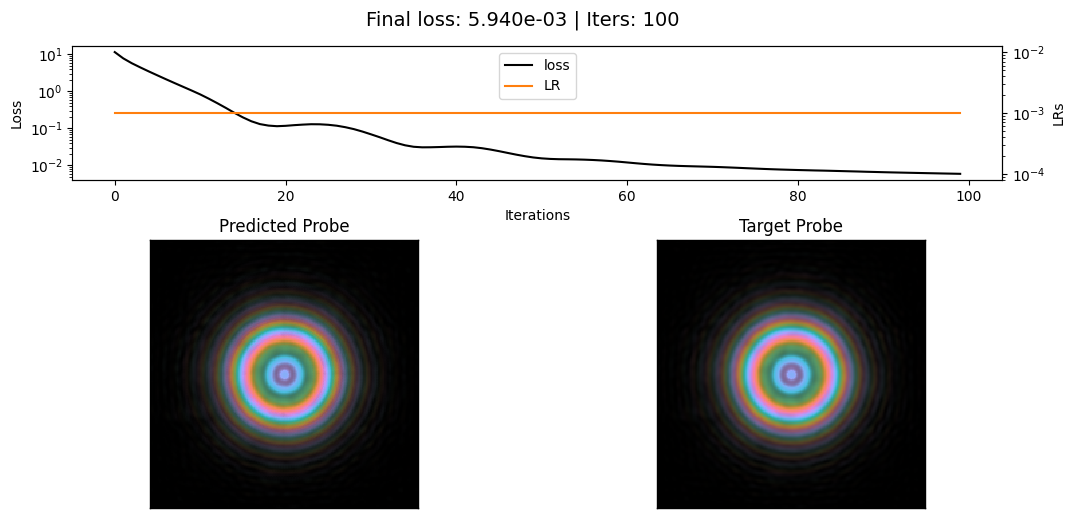

In [9]:
model_obj = CNN2d(
    in_channels=ptycho_pix2.num_slices,
    use_skip_connections=True,
    dtype=torch.float32,
    final_activation="identity",
)
obj_model_dip = ObjectDIP.from_pixelated(
    model=model_obj,
    pixelated=ptycho_pix2.obj_model,
)

model_probe = CNN2d(
    in_channels=1,
    use_skip_connections=True,
    dtype=torch.complex64,
)
probe_model_dip = ProbeDIP.from_pixelated(
    model=model_probe,
    pixelated=ptycho_pix2.probe_model,
)

obj_model_dip.pretrain(
    num_iters=100,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=0,
)
probe_model_dip.pretrain(
    num_iters=100,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=0,
)

# Save pretrained state so both runs start from the same point
obj_dip_pretrained = copy.deepcopy(obj_model_dip)
probe_dip_pretrained = copy.deepcopy(probe_model_dip)

## DIP — single GPU

Iter 50/50, Loss: 4.514e+00: 100%|██████████| 50/50 [00:24<00:00,  2.03it/s]


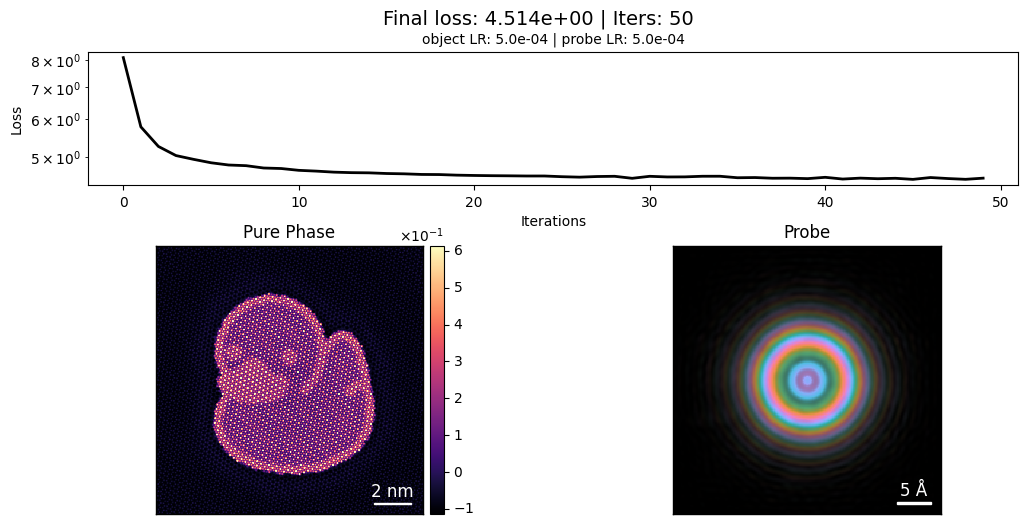

DIP 1 GPU — 50 iters — 25.3s


In [10]:
ptycho_dip_1gpu = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_dip,
    probe_model=probe_model_dip,
    detector_model=detector_model,
    rng=42,
)
ptycho_dip_1gpu.preprocess(obj_padding_px=(32, 32))

dip_opt = {
    "object": OptimizerParams.Adam(lr=5e-4),
    "probe": OptimizerParams.Adam(lr=5e-4),
}
dip_sched = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}

t0 = time.perf_counter()
ptycho_dip_1gpu.reconstruct(
    num_iters=50,
    reset=True,
    optimizer_params=dip_opt,
    scheduler_params=dip_sched,
    batch_size=128,
    device=GPU_IDS[0],
).visualize()
t_dip_1gpu = time.perf_counter() - t0
print(f"DIP 1 GPU — {ptycho_dip_1gpu.num_iters} iters — {t_dip_1gpu:.1f}s")

## DIP — multi-GPU

Iter 50/50, Loss: 4.544e+00: 100%|██████████| 50/50 [00:14<00:00,  3.43it/s]


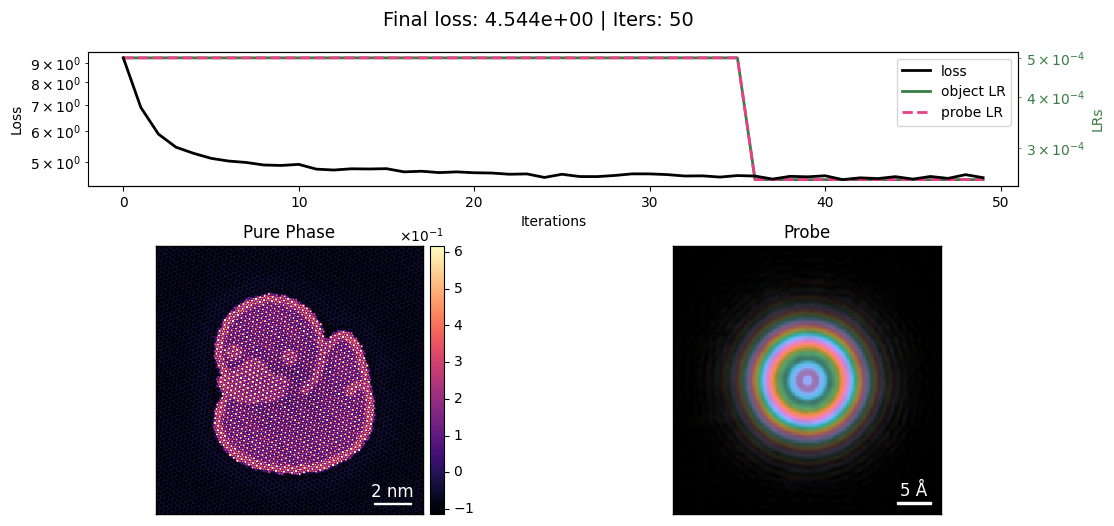

DIP 2 GPUs — 50 iters — 20.5s


In [11]:
ptycho_dip_mgpu = Ptychography.from_models(
    dset=pdset,
    obj_model=copy.deepcopy(obj_dip_pretrained),
    probe_model=copy.deepcopy(probe_dip_pretrained),
    detector_model=detector_model,
    rng=42,
)
ptycho_dip_mgpu.preprocess(obj_padding_px=(32, 32))
dip_opt_mgpu = {
    "object": OptimizerParams.Adam(lr=5e-4),
    "probe": OptimizerParams.Adam(lr=5e-4),
}

t0 = time.perf_counter()
ptycho_dip_mgpu.reconstruct(
    num_iters=50,
    reset=True,
    optimizer_params=dip_opt_mgpu,
    scheduler_params=dip_sched,
    batch_size=128,
    device=GPU_IDS,
).visualize()
t_dip_mgpu = time.perf_counter() - t0
print(f"DIP {len(GPU_IDS)} GPUs — {ptycho_dip_mgpu.num_iters} iters — {t_dip_mgpu:.1f}s")

## DIP: comparison
Both runs use the same global `batch_size=128`, so the loss curves should match more-or-less exactly — the multi-GPU run just gets there faster.

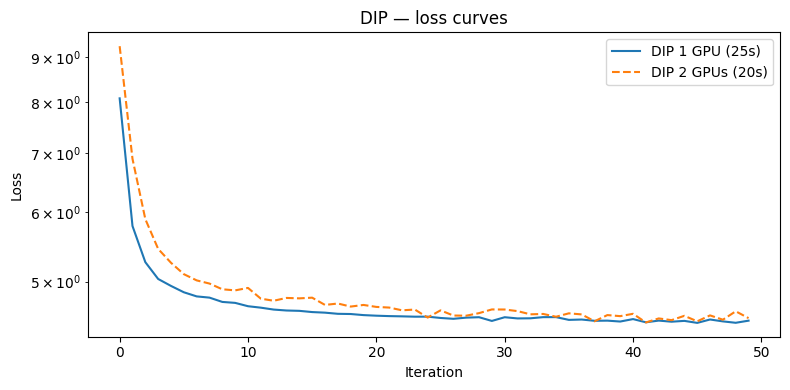

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'DIP 1 GPU | 50 iters'}>,
        <Axes: title={'center': 'DIP 2 GPUs | 50 iters'}>], dtype=object))

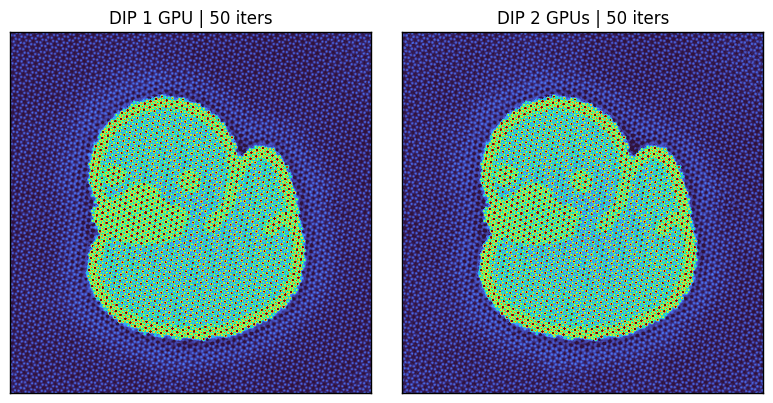

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ptycho_dip_1gpu._iter_losses, label=f"DIP 1 GPU ({t_dip_1gpu:.0f}s)")
ax.plot(ptycho_dip_mgpu._iter_losses, label=f"DIP {len(GPU_IDS)} GPUs ({t_dip_mgpu:.0f}s)", linestyle="--")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.set_title("DIP — loss curves")
plt.tight_layout()
plt.show()

ph_dip_1gpu = ptycho_dip_1gpu.obj_cropped.sum(0)
ph_dip_mgpu = ptycho_dip_mgpu.obj_cropped.sum(0)
show_2d(
    [ph_dip_1gpu, ph_dip_mgpu],
    cmap="turbo",
    title=[
        f"DIP 1 GPU | {ptycho_dip_1gpu.num_iters} iters",
        f"DIP {len(GPU_IDS)} GPUs | {ptycho_dip_mgpu.num_iters} iters",
    ],
)

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'DIP 2 GPUs 50 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

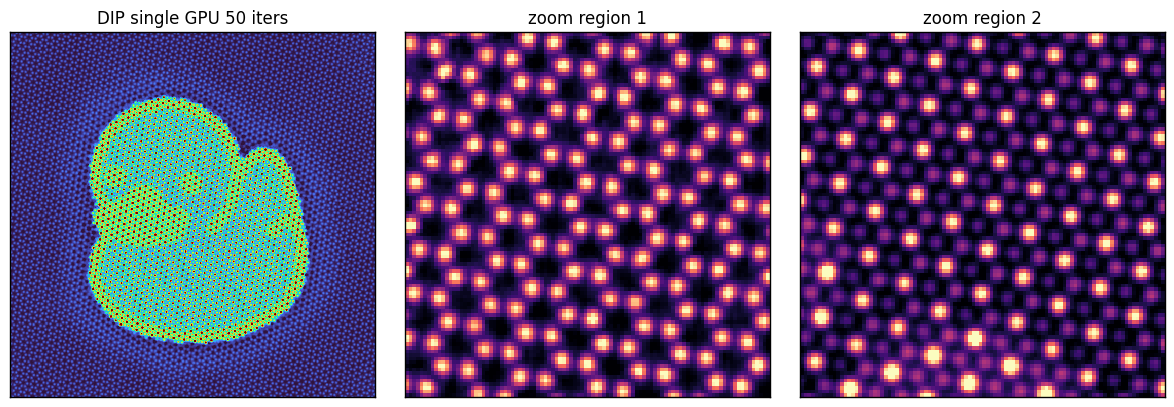

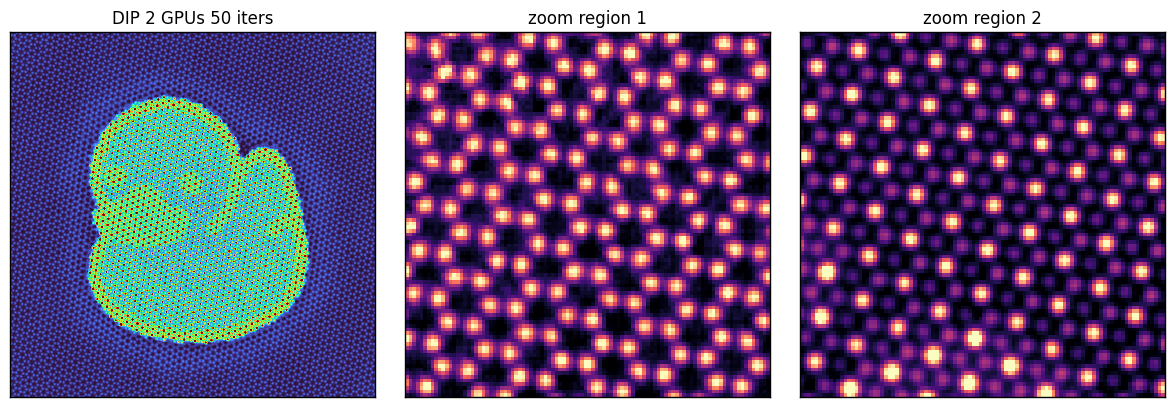

In [13]:
r1 = slice(10, 110), slice(10, 110)
r2 = slice(220, 320), slice(220, 320)
ph_1gpu = ptycho_dip_1gpu.obj_cropped.sum(0)
if ptycho_dip_1gpu.obj_model.obj_type == "complex":
    ph_1gpu = np.angle(ph_1gpu)
show_2d(
    [
        ph_1gpu,
        ph_1gpu[r1],
        ph_1gpu[r2],
    ],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"DIP single GPU {ptycho_dip_1gpu.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

ph_mgpu = ptycho_dip_mgpu.obj_cropped.sum(0)
if ptycho_dip_mgpu.obj_model.obj_type == "complex":
    ph_mgpu = np.angle(ph_mgpu)
show_2d(
    [
        ph_mgpu,
        ph_mgpu[r1],
        ph_mgpu[r2],
    ],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"DIP {len(GPU_IDS)} GPUs {ptycho_dip_mgpu.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

## Larger-than-VRAM datasets — streaming targets from CPU

For datasets where even the sharded diffraction targets won't fit in a single GPU's VRAM, set `pdset.target_residency = "cpu"` *before* calling `reconstruct(...)`. The targets stay in pinned host RAM and the DataLoader prefetches them per-batch. Add `num_workers >= 1` so the host→device copy runs in a background process and overlaps with the previous batch's compute.

The ducky dataset is small enough to fit comfortably in VRAM, so this is purely illustrative — but the exact same code works on a multi-hundred-GB experimental dataset. Expect a small per-iteration overhead (typically 5–15%) on top of the device-resident path; the wall-clock difference shrinks as `num_probes` and the forward graph grow.

**Recipe:**
1. Build `pdset` and preprocess as usual.
2. Set `pdset.target_residency = "cpu"` once.
3. Call `reconstruct(..., num_workers=2)` — quantEM enables `pin_memory=True` and a spawn-context worker pool automatically.

The reconstruction below uses the same hyperparameters as the multi-GPU pixelated run above and should produce a numerically equivalent loss trajectory.

Iter 500/500, Loss: 4.385e+00: 100%|██████████| 500/500 [00:32<00:00, 15.58it/s]


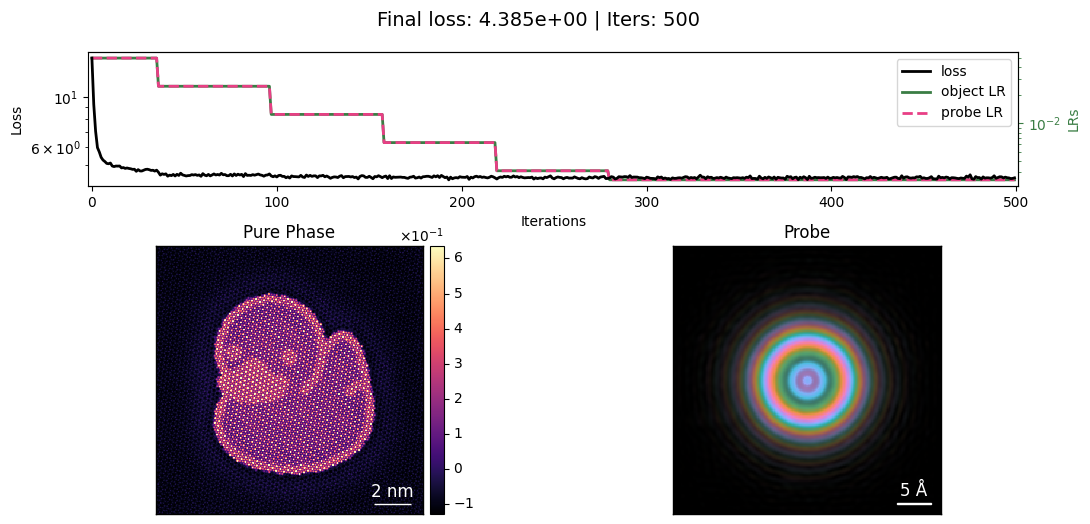

2 GPUs (streaming) — 500 iters — 38.3s


In [16]:
ptycho_stream = Ptychography.from_models(
    dset=pdset,
    obj_model=ObjectPixelated.from_uniform(obj_type="pure_phase", num_slices=1),
    probe_model=ProbePixelated.from_params(
        probe_params={"energy": PROBE_ENERGY, "defocus": PROBE_DEFOCUS, "semiangle_cutoff": PROBE_SEMIANGLE}
    ),
    detector_model=detector_model,
    rng=42,
)
ptycho_stream.preprocess(obj_padding_px=(32, 32))

# The single knob: targets stay on CPU, streamed per-batch
pdset.target_residency = "cpu"

t0 = time.perf_counter()
ptycho_stream.reconstruct(
    num_iters=500,
    reset=True,
    optimizer_params=pix_opt_mgpu,
    scheduler_params=sched,
    batch_size=128,
    device=GPU_IDS,
    num_workers=2,        # background prefetch hides host->device transfer
).visualize()
t_stream = time.perf_counter() - t0
print(f"{len(GPU_IDS)} GPUs (streaming) — {ptycho_stream.num_iters} iters — {t_stream:.1f}s")

# Restore device residency for any downstream cells in this notebook
pdset.target_residency = "device"


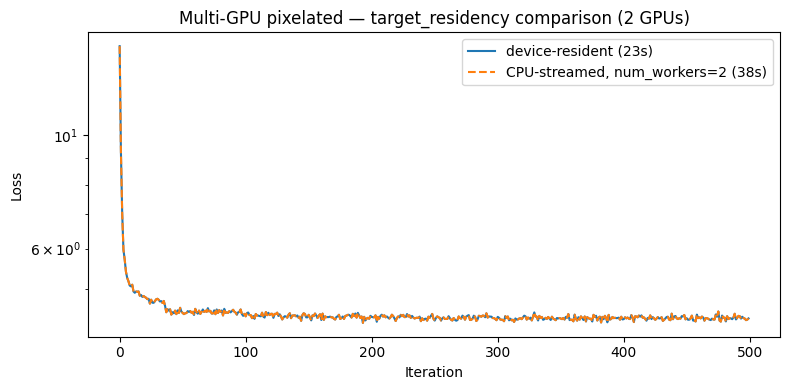

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ptycho_mgpu._iter_losses, label=f"device-resident ({t_mgpu:.0f}s)")
ax.plot(ptycho_stream._iter_losses, label=f"CPU-streamed, num_workers=2 ({t_stream:.0f}s)", linestyle="--")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.set_title(f"Multi-GPU pixelated — target_residency comparison ({len(GPU_IDS)} GPUs)")
plt.tight_layout()
plt.show()

## Notes

**Startup overhead.** Process spawning, NCCL initialization, and state serialization add a fixed overhead per `reconstruct()` call. Use longer `num_iters` per call to amortize.

**Batch size is global.** With W GPUs and `batch_size=B`, each rank processes `B // W` samples per step (a warning is emitted when `B` isn't evenly divisible by W) and gradients are all-reduced, so each optimizer step averages over the same B samples as a single-GPU run. The same `B` reproduces the same optimization trajectory on any number of GPUs — there is no need to divide `batch_size` by the GPU count or to rescale the learning rate when changing the GPU count.

**Memory knobs at a glance.**
- `batch_size` — controls the transient forward/backward graph size; per-GPU transients scale with `batch_size / W`. Lower it (or add GPUs) if the transients don't fit.
- `pdset.target_residency` — `"device"` (default, fastest) or `"cpu"` (streams targets from host RAM, enables larger-than-VRAM reconstructions). Set before `reconstruct()`.
- `num_workers` — `0` (default; in-process loader) or `>=1` (background prefetch). Only useful with `target_residency="cpu"`; values of 1–2 per GPU typically hide host→device transfer overhead.
- `device=[i, j, ...]` — shards the target tensor across listed GPUs (per-GPU target footprint scales as 1/W) and splits each batch across them (per-GPU transients scale as `batch_size / W`).

**Diagnosing OOMs.**
- OOM at iter 1, before any forward pass → targets don't fit. Use more GPUs (`device=[...]`), or switch to `target_residency="cpu"`.
- OOM mid-iteration → forward/backward transients don't fit. Lower `batch_size` or add GPUs (each GPU only processes `batch_size / W` per step).

**Multi-node.** For multi-node runs (e.g. NERSC/Perlmutter), use `torchrun` instead of the notebook spawn path. Set `RANK`, `LOCAL_RANK`, and `WORLD_SIZE` as usual — quantEM detects them automatically and skips the internal spawn. See `hpc/README.md` for a SLURM example.